### Data : fingers

https://drive.google.com/file/d/1E8IPKBjSLF9UN9UZQtaI0slHScXZcMr2/view?usp=sharing

In [1]:
import glob
import matplotlib.pyplot as plt
from PIL import Image

In [25]:
# 파일명 불러오기 : 파일명에 target 값이 들어있음
train_images = glob.glob("../Data/fingers/train/*.png")
test_images = glob.glob('../Data/fingers/test/*.png')

In [30]:
# file name 확인
test_images[:5]

['../Data/fingers/test\\000e7aa6-100b-4c6b-9ff0-e7a8e53e4465_5L.png',
 '../Data/fingers/test\\001f6021-8581-4ed2-aed4-cda0af1d5d57_5L.png',
 '../Data/fingers/test\\0027029b-4c3c-4785-bc1b-b8141331a108_3R.png',
 '../Data/fingers/test\\004599fb-c735-4ff3-a969-342dda319382_5L.png',
 '../Data/fingers/test\\00500e1a-f4bd-4f66-9eb8-c7fce19a3f6f_5L.png']

In [ ]:
# 이미지 size 확인
testImg = Image.open(train_images[0])
testImg.size

(128, 128)

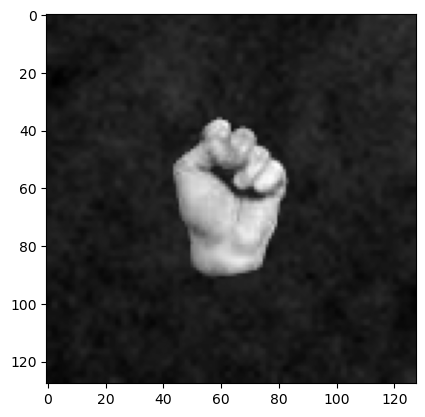

In [9]:
# 이미지 확인
plt.imshow(testImg, cmap='gray')
plt.show()

----
### Dataset 구성 작업

#### Train Data 구성

In [31]:
import numpy as np

# train / test data 구성
train_input = []
test_input = []
train_target = []
test_target = []


# train data
for image in sorted(train_images):
    with Image.open(image) as img:
        img = np.array(img, dtype = np.int32)
        train_input.append(img)
        train_target.append(image[-6:-4])

# test data
for image in sorted(test_images):
    with Image.open(image) as img:
        img = np.array(img, dtype = np.int32)
        test_input.append(img)
        test_target.append(image[-6:-4])

In [32]:
train_input = np.array(train_input)
test_input = np.array(test_input)
print(train_input.shape)
print(test_input.shape)

(18000, 128, 128)
(3600, 128, 128)


In [ ]:
# 정규화
train_input = train_input / 255.0
test_input = test_input / 255.0

# channel 추가 (흑백 : 1)
train_input = train_input.reshape(-1, 128, 128, 1)
test_input = test_input.reshape(-1, 128, 128, 1)

train_input[:5]

array([[[[0.21176471],
         [0.20784314],
         [0.2       ],
         ...,
         [0.25098039],
         [0.25882353],
         [0.2627451 ]],

        [[0.21176471],
         [0.20784314],
         [0.19607843],
         ...,
         [0.25882353],
         [0.2627451 ],
         [0.26666667]],

        [[0.21568627],
         [0.20784314],
         [0.19215686],
         ...,
         [0.27843137],
         [0.2745098 ],
         [0.27058824]],

        ...,

        [[0.16470588],
         [0.16470588],
         [0.17254902],
         ...,
         [0.25490196],
         [0.25098039],
         [0.25098039]],

        [[0.17254902],
         [0.16862745],
         [0.16470588],
         ...,
         [0.25490196],
         [0.2627451 ],
         [0.26666667]],

        [[0.17647059],
         [0.17254902],
         [0.16078431],
         ...,
         [0.25490196],
         [0.26666667],
         [0.2745098 ]]],


       [[[0.21176471],
         [0.20784314],
         [0.20

#### Target data 구성

In [33]:
train_target[:5]

['0L', '0L', '2L', '0L', '5L']

In [34]:
# 숫자로 바꾸기
label_to_int = {
    '0R' : 0,
    '1R' : 1,
    '2R' : 2,
    '3R' : 3,
    '4R' : 4,
    '5R' : 5,
    '0L' : 6,
    '1L' : 7,
    '2L' : 8,
    '3L' : 9,
    '4L' : 10,
    '5L' : 11,
}

temp =[]
for label in train_target:
    temp.append(label_to_int[label])

train_target = temp.copy()
train_target

[6,
 6,
 8,
 6,
 11,
 5,
 2,
 2,
 9,
 0,
 10,
 8,
 6,
 7,
 2,
 3,
 6,
 9,
 5,
 5,
 4,
 6,
 2,
 2,
 0,
 11,
 6,
 6,
 9,
 3,
 8,
 7,
 0,
 6,
 11,
 10,
 7,
 0,
 4,
 10,
 11,
 1,
 2,
 2,
 11,
 9,
 9,
 4,
 11,
 3,
 2,
 2,
 2,
 8,
 5,
 0,
 5,
 5,
 2,
 8,
 4,
 3,
 5,
 0,
 6,
 10,
 7,
 0,
 8,
 0,
 7,
 11,
 6,
 4,
 8,
 9,
 7,
 0,
 3,
 2,
 2,
 0,
 1,
 0,
 11,
 1,
 1,
 7,
 2,
 2,
 7,
 2,
 2,
 11,
 3,
 4,
 7,
 0,
 5,
 8,
 1,
 11,
 11,
 5,
 2,
 10,
 8,
 10,
 0,
 8,
 11,
 3,
 9,
 1,
 1,
 1,
 5,
 7,
 10,
 4,
 0,
 4,
 3,
 8,
 11,
 2,
 1,
 8,
 3,
 8,
 8,
 1,
 4,
 11,
 9,
 1,
 7,
 4,
 2,
 11,
 8,
 6,
 4,
 7,
 6,
 1,
 5,
 2,
 10,
 8,
 5,
 10,
 1,
 9,
 1,
 2,
 1,
 6,
 5,
 4,
 11,
 0,
 0,
 6,
 11,
 7,
 6,
 1,
 5,
 10,
 1,
 6,
 4,
 8,
 9,
 5,
 4,
 0,
 0,
 11,
 8,
 9,
 1,
 3,
 0,
 6,
 6,
 0,
 11,
 7,
 2,
 10,
 0,
 4,
 1,
 9,
 1,
 8,
 9,
 0,
 9,
 6,
 11,
 3,
 10,
 8,
 1,
 10,
 10,
 6,
 6,
 0,
 5,
 3,
 1,
 2,
 10,
 5,
 10,
 10,
 6,
 4,
 3,
 9,
 10,
 7,
 8,
 9,
 2,
 0,
 9,
 4,
 5,
 10,
 0,
 9,
 3,
 5,
 4,
 11,


In [35]:
temp =[]
for label in test_target:
    temp.append(label_to_int[label])

test_target = temp.copy()
test_target[:5]

[11, 11, 3, 11, 11]

In [36]:
# target data도 numpy array로 변경
train_target = np.array(train_target)
test_target = np.array(test_target)

test_target[:5]

array([11, 11,  3, 11, 11])

----
### CNN 모델 생성

In [43]:
from tensorflow import keras

In [44]:
model = keras.Sequential()

model.add(
    keras.layers.Conv2D(
        32,
        kernel_size= 3,
        activation= 'relu',
        padding = 'same',
        input_shape = (128, 128, 1)
    )
)

model.add(
    keras.layers.MaxPooling2D(2)
)

c:\ProgramData\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [45]:
# Dense 층

# 입력층
model.add(
    keras.layers.Flatten()      # input size 모름 -> 그냥 1차원으로 펴버림
)

# 은닉층
model.add(
    keras.layers.Dense(
        100,
        activation= 'relu'
    )
)

# Drop out 층
model.add(
    keras.layers.Dropout(0.5)
)

# 출력층
model.add(
    keras.layers.Dense(
        12,
        activation= 'softmax'
    )
)

In [46]:
# 확인
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 128, 128, 32)        │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 64, 64, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 131072)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 100)                 │      13,107,300 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 100)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 12)                  │           1,212 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 13,108,832 (50.01 MB)

 Trainable params: 13,108,832 (50.01 MB)

 Non-trainable params: 0 (0.00 B)

In [47]:
# Compile

model.compile(
    loss ='sparse_categorical_crossentropy',
    optimizer = 'adam',
    metrics = ['accuracy']
)

checkpoint_cb = keras.callbacks.ModelCheckpoint(
                    '../Data/best_cnn_model.keras',
                    save_best_only=True
)
early_stopping_cb = keras.callbacks.EarlyStopping(
                        patience = 3,
                        restore_best_weights = True
)

In [48]:
from sklearn.model_selection import train_test_split
# train -> train + val 분리
train_scaled, val_scaled, train_target, val_target = \
    train_test_split(
        train_input,
        train_target,
        test_size=0.2,
        random_state= 42
    )

In [49]:
# 학습
history = model.fit(
                train_scaled,
                train_target,
                epochs = 100,
                validation_data = (val_scaled, val_target),
                callbacks = [checkpoint_cb, early_stopping_cb]
)

Epoch 1/100
450/450 ━━━━━━━━━━━━━━━━━━━━ 102s 219ms/step - accuracy: 0.3500 - loss: 1.7373 - val_accuracy: 0.9689 - val_loss: 0.5305
Epoch 2/100
450/450 ━━━━━━━━━━━━━━━━━━━━ 89s 197ms/step - accuracy: 0.5353 - loss: 1.1344 - val_accuracy: 0.9883 - val_loss: 0.2606
Epoch 3/100
450/450 ━━━━━━━━━━━━━━━━━━━━ 89s 197ms/step - accuracy: 0.5690 - loss: 1.0249 - val_accuracy: 0.9872 - val_loss: 0.1983
Epoch 4/100
450/450 ━━━━━━━━━━━━━━━━━━━━ 89s 197ms/step - accuracy: 0.6219 - loss: 0.9134 - val_accuracy: 0.9922 - val_loss: 0.1720
Epoch 5/100
450/450 ━━━━━━━━━━━━━━━━━━━━ 89s 197ms/step - accuracy: 0.6430 - loss: 0.8826 - val_accuracy: 0.9969 - val_loss: 0.1694
Epoch 6/100
450/450 ━━━━━━━━━━━━━━━━━━━━ 91s 202ms/step - accuracy: 0.6569 - loss: 0.8671 - val_accuracy: 0.9964 - val_loss: 0.1421
Epoch 7/100
450/450 ━━━━━━━━━━━━━━━━━━━━ 90s 199ms/step - accuracy: 0.6652 - loss: 0.8338 - val_accuracy: 0.9986 - val_loss: 0.1173
Epoch 8/100
450/450 ━━━━━━━━━━━━━━━━━━━━ 89s 198ms/step - accuracy: 0.6770 

In [ ]:
# test... 등등....